In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F, Window
from pyspark.sql.functions import col
from pyspark.sql.types import StringType
import numpy as np
import matplotlib.pyplot as plt
import re
import time

In [2]:
spark = SparkSession \
    .builder \
    .appName("Midterm") \
    .config("spark.master", "local[*]") \
    .getOrCreate()

In [3]:
spark

In [4]:
orders_path = "data/orders.csv"
products_path = "data/products.csv"
order_products_prior_path = "data/order_products__prior.csv"
order_products_train_path = "data/order_products__train.csv"
aisles_path = "data/aisles.csv"
departments_path = "data/departments.csv"

In [5]:
orders = spark.read \
              .option("header", True) \
              .option("inferSchema", True) \
              .csv(orders_path)

products = spark.read \
                .option("header", True) \
                .option("inferSchema", False) \
                .option("quote", '"') \
                .option("escape", '"') \
                .option("multiLine", True) \
                .csv(products_path)

order_products_prior = spark.read \
                            .option("header", True) \
                            .option("inferSchema", True) \
                            .csv(order_products_prior_path)

order_products_train = spark.read \
                            .option("header", True) \
                            .option("inferSchema", True) \
                            .csv(order_products_train_path)

aisles = spark.read \
              .option("header", True) \
              .option("inferSchema", True) \
              .csv(aisles_path)


departments = spark.read \
                   .option("header", True) \
                   .option("inferSchema", True) \
                   .csv(departments_path)

In [6]:
aisles.count()

134

In [7]:
aisles.show(10)

+--------+--------------------+
|aisle_id|               aisle|
+--------+--------------------+
|       1|prepared soups sa...|
|       2|   specialty cheeses|
|       3| energy granola bars|
|       4|       instant foods|
|       5|marinades meat pr...|
|       6|               other|
|       7|       packaged meat|
|       8|     bakery desserts|
|       9|         pasta sauce|
|      10|    kitchen supplies|
+--------+--------------------+
only showing top 10 rows


In [8]:
aisles.printSchema()

root
 |-- aisle_id: integer (nullable = true)
 |-- aisle: string (nullable = true)



In [9]:
products.count()

49688

In [10]:
products.show(10)

+----------+--------------------+--------+-------------+
|product_id|        product_name|aisle_id|department_id|
+----------+--------------------+--------+-------------+
|         1|Chocolate Sandwic...|      61|           19|
|         2|    All-Seasons Salt|     104|           13|
|         3|Robust Golden Uns...|      94|            7|
|         4|Smart Ones Classi...|      38|            1|
|         5|Green Chile Anyti...|       5|           13|
|         6|        Dry Nose Oil|      11|           11|
|         7|Pure Coconut Wate...|      98|            7|
|         8|Cut Russet Potato...|     116|            1|
|         9|Light Strawberry ...|     120|           16|
|        10|Sparkling Orange ...|     115|            7|
+----------+--------------------+--------+-------------+
only showing top 10 rows


In [11]:
products.printSchema()

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)



In [12]:
departments.count()

21

In [13]:
departments.show(10)

+-------------+---------------+
|department_id|     department|
+-------------+---------------+
|            1|         frozen|
|            2|          other|
|            3|         bakery|
|            4|        produce|
|            5|        alcohol|
|            6|  international|
|            7|      beverages|
|            8|           pets|
|            9|dry goods pasta|
|           10|           bulk|
+-------------+---------------+
only showing top 10 rows


In [14]:
departments.printSchema()

root
 |-- department_id: integer (nullable = true)
 |-- department: string (nullable = true)



In [15]:
order_products_prior.count()

32434489

In [16]:
order_products_prior.show(10)

+--------+----------+-----------------+---------+
|order_id|product_id|add_to_cart_order|reordered|
+--------+----------+-----------------+---------+
|       2|     33120|                1|        1|
|       2|     28985|                2|        1|
|       2|      9327|                3|        0|
|       2|     45918|                4|        1|
|       2|     30035|                5|        0|
|       2|     17794|                6|        1|
|       2|     40141|                7|        1|
|       2|      1819|                8|        1|
|       2|     43668|                9|        0|
|       3|     33754|                1|        1|
+--------+----------+-----------------+---------+
only showing top 10 rows


In [17]:
order_products_prior.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)



In [18]:
order_products_train.count()

1384617

In [19]:
order_products_train.show(10)

+--------+----------+-----------------+---------+
|order_id|product_id|add_to_cart_order|reordered|
+--------+----------+-----------------+---------+
|       1|     49302|                1|        1|
|       1|     11109|                2|        1|
|       1|     10246|                3|        0|
|       1|     49683|                4|        0|
|       1|     43633|                5|        1|
|       1|     13176|                6|        0|
|       1|     47209|                7|        0|
|       1|     22035|                8|        1|
|      36|     39612|                1|        0|
|      36|     19660|                2|        1|
+--------+----------+-----------------+---------+
only showing top 10 rows


In [20]:
order_products_train.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)



In [21]:
orders.count()

3421083

In [22]:
orders.show(10)

+--------+-------+--------+------------+---------+-----------------+----------------------+
|order_id|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|
+--------+-------+--------+------------+---------+-----------------+----------------------+
| 2539329|      1|   prior|           1|        2|                8|                  NULL|
| 2398795|      1|   prior|           2|        3|                7|                  15.0|
|  473747|      1|   prior|           3|        3|               12|                  21.0|
| 2254736|      1|   prior|           4|        4|                7|                  29.0|
|  431534|      1|   prior|           5|        4|               15|                  28.0|
| 3367565|      1|   prior|           6|        2|                7|                  19.0|
|  550135|      1|   prior|           7|        1|                9|                  20.0|
| 3108588|      1|   prior|           8|        1|               14|            

In [23]:
orders.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |-- days_since_prior_order: double (nullable = true)



# Data Quality Analysis (2 pts)

### Problem 1:

In [24]:
orders.filter(col("days_since_prior_order").isNull()).count()

206209

In [25]:
invalid_nulls = orders.filter(
    (col("days_since_prior_order").isNull()) &
    (col("order_number") != 1)
)

invalid_nulls.count()

0

Problem: days_since_prior_order column has 206209 null values, since these are the first ever order per each user

Impact: aggregations like average days between orders will exclude these rows or throw errors. Any time-based customer behavior analysis could be skewed.

Fix: filter out when calculating reorder intervals, or flag them as "first_order = True".


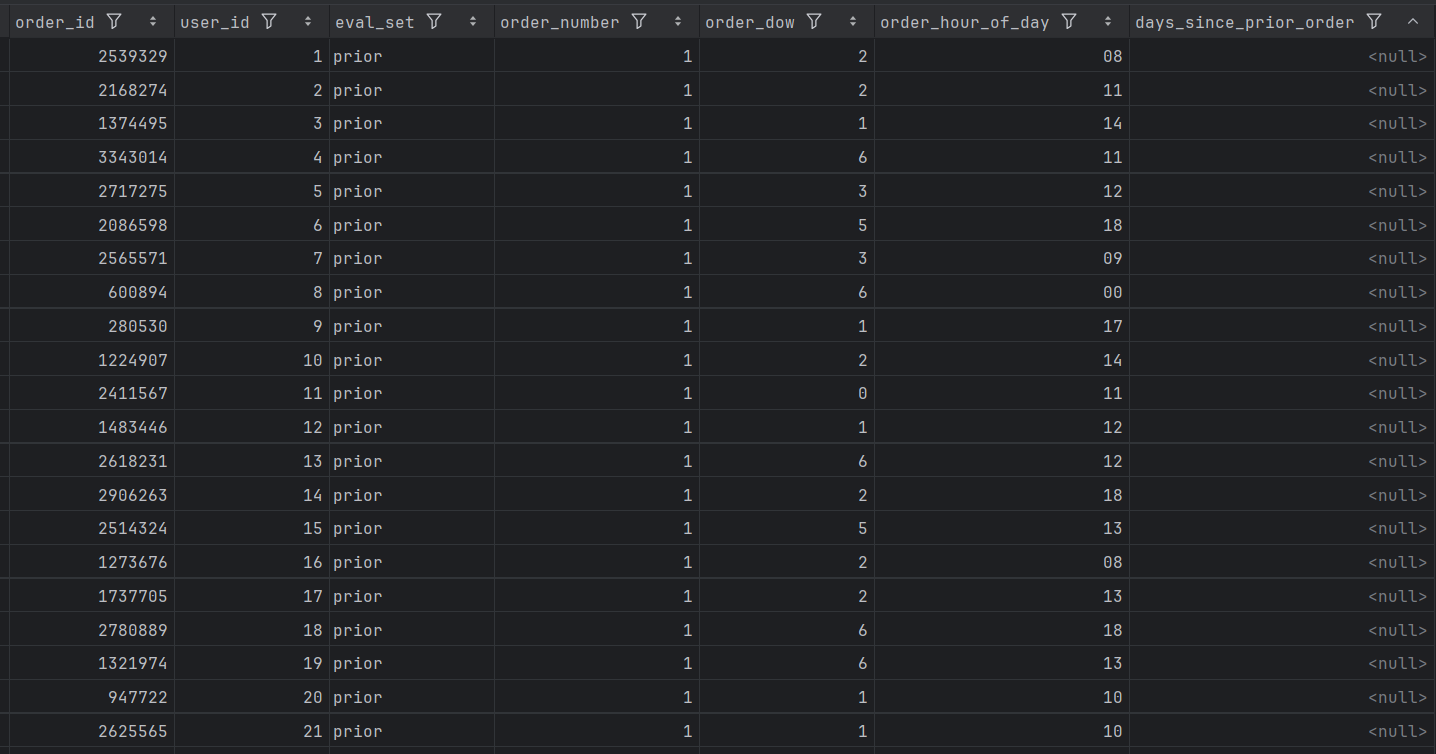

### Problem 2:

In [26]:
products.printSchema()

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)



In [27]:
products = products.withColumn("product_id", col("product_id").cast("integer")) \
                   .withColumn("aisle_id", col("aisle_id").cast("integer")) \
                   .withColumn("department_id", col("department_id").cast("integer"))

In [28]:
products.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: integer (nullable = true)
 |-- department_id: integer (nullable = true)



**Problem:** products table's columns aisle_id and department_id are type of string

**Impact:**
* Join Failures: Joining products.aisle_id (string) with aisles.aisle_id (integer) will fail or silently produce incorrect results due to type mismatch.
* Performance: String comparisons are slower than integer comparisons

**Fix:** Convert to integer

### Problem 3:

**Problem:** In order_products_prior, the reordered column is 0 for a user's first order regardless of whether the product is commonly reordered, because there's no history to compare against.

**Impact:** Products that appear mostly in first-time orders will have artificially low reorder rates. This can skew product popularity and recommendation analysis.

**Fix:** Exclude first orders (order_number = 1) when calculating reorder rates.


### Problem 4:

**Problem:** Reading CSV issue, where product's id was ' Blunted'

**Impact:** joining issues

**Fix:** reload the CSV with explicit parsing options and validate the identifier columns before casting them to integer type.


```
products = spark.read \
                .option("header", True) \
                .option("inferSchema", False) \
                .option("quote", '"') \
                .option("escape", '"') \
                .option("multiLine", True) \
                .csv(products_path)
```

### Validation check

In [29]:
# Validation check: add_to_cart_order is sequential without gaps
gap_check = order_products_prior.groupBy("order_id").agg(
    F.min("add_to_cart_order").alias("min_pos"),
    F.max("add_to_cart_order").alias("max_pos"),
    F.count("*").alias("count")
).filter((F.col("min_pos") != 1) | (F.col("max_pos") != F.col("count")))

print(f"Orders with non-sequential add_to_cart_order: {gap_check.count()}")


# order_hour_of_day must be 0-23
bad_hours = orders.filter((F.col("order_hour_of_day") < 0) | (F.col("order_hour_of_day") > 23))

print(f"Rows with invalid order_hour_of_day: {bad_hours.count()}")


# order_dow must be 0-6
bad_dow = orders.filter((F.col("order_dow") < 0) | (F.col("order_dow") > 6))

print(f"Rows with invalid order_dow: {bad_dow.count()}")


# reordered must be 0 or 1
bad_reordered = order_products_prior.filter(~F.col("reordered").isin(0, 1))

print(f"Rows with invalid reordered value: {bad_reordered.count()}")


# (order_id, product_id) pairs must be unique
total_rows = order_products_prior.count()
distinct_pairs = order_products_prior.select("order_id", "product_id").distinct().count()

print(f"Duplicate (order_id, product_id) pairs: {total_rows - distinct_pairs}")

Orders with non-sequential add_to_cart_order: 0
Rows with invalid order_hour_of_day: 0
Rows with invalid order_dow: 0
Rows with invalid reordered value: 0
Duplicate (order_id, product_id) pairs: 0


**Valid checks:**

*   add_to_cart_order -> sequentially, without any gap
*   order_hour_of_day -> 0-23
*   reordered -> 0/1
*   order_dow -> 0-6
*   (order_id, product_id) pairs -> 0 duplicates

# 2) Data Manipulation, Joins, and UDF (2 pts)


In [30]:
# Flag first orders as TRUE
orders_cleaned = orders.withColumn(
    "is_first_order",
    F.when(F.col("days_since_prior_order").isNull(), True).otherwise(False)
).withColumn(
    "days_since_prior_order",
    F.when(F.col("days_since_prior_order").isNull(), 0)
     .otherwise(F.col("days_since_prior_order"))
)

In [31]:
# Combine prior and train order products to get product ordering history
order_products_all = order_products_prior.unionByName(order_products_train)

In [32]:
order_products_all.count()

33819106

In [33]:
# checkng for duplicate pairs
all_op_deduped = order_products_all.dropDuplicates(["order_id", "product_id"])

In [34]:
all_op_deduped.count() # no duplicates, since the count of rows is the same

33819106

In [35]:
# cleaned dataset
cleaned_dataset = order_products_all \
    .join(orders_cleaned, on="order_id", how="inner") \
    .join(products, on="product_id", how="inner") \
    .join(aisles, on="aisle_id", how="inner") \
    .join(departments, on="department_id", how="inner")

In [36]:
cleaned_dataset.count()

33819106

In [37]:
cleaned_dataset.show(15)

+-------------+--------+----------+--------+-----------------+---------+-------+--------+------------+---------+-----------------+----------------------+--------------+--------------------+--------------------+------------+
|department_id|aisle_id|product_id|order_id|add_to_cart_order|reordered|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|is_first_order|        product_name|               aisle|  department|
+-------------+--------+----------+--------+-----------------+---------+-------+--------+------------+---------+-----------------+----------------------+--------------+--------------------+--------------------+------------+
|           16|      53|     30597|      12|                1|        1| 152610|   prior|          22|        6|                8|                  10.0|         false|French Vanilla Co...|               cream|  dairy eggs|
|           16|      84|     15221|      12|                2|        1| 152610|   prior|          22|  

In [38]:
cleaned_dataset.select(*[F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in cleaned_dataset.columns]).show()

+-------------+--------+----------+--------+-----------------+---------+-------+--------+------------+---------+-----------------+----------------------+--------------+------------+-----+----------+
|department_id|aisle_id|product_id|order_id|add_to_cart_order|reordered|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|is_first_order|product_name|aisle|department|
+-------------+--------+----------+--------+-----------------+---------+-------+--------+------------+---------+-----------------+----------------------+--------------+------------+-----+----------+
|            0|       0|         0|       0|                0|        0|      0|       0|           0|        0|                0|                     0|             0|           0|    0|         0|
+-------------+--------+----------+--------+-----------------+---------+-------+--------+------------+---------+-----------------+----------------------+--------------+------------+-----+----------+



In [39]:
cleaned_dataset.printSchema()

root
 |-- department_id: integer (nullable = true)
 |-- aisle_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |-- days_since_prior_order: double (nullable = true)
 |-- is_first_order: boolean (nullable = false)
 |-- product_name: string (nullable = true)
 |-- aisle: string (nullable = true)
 |-- department: string (nullable = true)



### Top 3 products per user (by frequency)

In [40]:
# Product purchase count per user
user_product_freq = cleaned_dataset.groupBy("user_id", "product_id") \
                    .agg(F.count("*").alias("purchase_count"))

user_product_ranked = user_product_freq.withColumn("rank", F.row_number().over(Window.partitionBy("user_id")\
              .orderBy(F.desc("purchase_count"))))

top3_per_user = user_product_ranked.filter(F.col("rank") <= 3)

top3_per_user.orderBy("user_id", "rank").show(15, truncate=False)

+-------+----------+--------------+----+
|user_id|product_id|purchase_count|rank|
+-------+----------+--------------+----+
|1      |196       |11            |1   |
|1      |10258     |10            |2   |
|1      |12427     |10            |3   |
|2      |32792     |10            |1   |
|2      |47209     |8             |2   |
|2      |24852     |8             |3   |
|3      |39190     |10            |1   |
|3      |47766     |9             |2   |
|3      |21903     |8             |3   |
|4      |35469     |2             |1   |
|4      |42329     |1             |2   |
|4      |1200      |1             |3   |
|5      |26604     |4             |1   |
|5      |11777     |4             |2   |
|5      |40706     |3             |3   |
+-------+----------+--------------+----+
only showing top 15 rows


### Normalized product names (group similar products in subgroups)

In [41]:
def normalize_product_name(name):
    if name is None:
        return "unknown"

    # Step 1: Lowercase
    normalized = name.lower().strip()

    # Step 2: Remove quantity/size patterns (e.g., "64 oz", "1.5 l", "12 ct", "6 pack")
    normalized = re.sub(r'\d+\.?\d*\s*(oz|fl\s*oz|ml|l|lb|lbs|kg|g|ct|count|pack|pk|pt|qt|gal|gallon|each|ea|in|inch)', '', normalized)

    # Step 3: Remove standalone numbers
    normalized = re.sub(r'\b\d+\.?\d*\b', '', normalized)

    # Step 4: Remove common prefixes that prevent grouping
    prefixes_to_remove = [
        'organic', 'natural', 'all natural', 'original', 'extra',
        'premium', 'classic', 'traditional', 'homestyle', 'all',
        'old fashioned', 'artisan', 'craft', 'fresh', 'en croute',
        'smartblend', 'healthy metabolism', 'dry', 'handmade', 'chunky'
    ]
    for prefix in prefixes_to_remove:
        normalized = re.sub(r'\b' + prefix + r'\b', '', normalized)

    # Step 5: Remove special characters (keep letters, spaces, hyphens)
    normalized = re.sub(r'[^a-z\s\-]', '', normalized)

    # Step 6: Collapse multiple spaces and trim
    normalized = re.sub(r'\s+', ' ', normalized).strip()

    # Step 7: Remove leading/trailing hyphens
    normalized = normalized.strip('-').strip()

    return normalized if normalized else "unknown"

I think there is no need to group similar products in subgroups, because aisle column contain a good common description for each product group

In [42]:
normalize_udf = F.udf(normalize_product_name, StringType())

# Apply normalization
cleaned_dataset = cleaned_dataset.withColumn(
    "normalized_name", normalize_udf(F.col("product_name"))
)

print("Product Name Normalization Examples")
cleaned_dataset.select("product_name", "normalized_name") \
                   .show(20, truncate=False)

Product Name Normalization Examples
+----------------------------------------------------------+----------------------------------------------------------+
|product_name                                              |normalized_name                                           |
+----------------------------------------------------------+----------------------------------------------------------+
|French Vanilla Coffee Creamer                             |french vanilla coffee creamer                             |
|2% Milk                                                   |milk                                                      |
|Cherubs Heavenly Salad Tomatoes                           |cherubs heavenly salad tomatoes                           |
|Extra Creamy Dairy Whipped Topping                        |creamy dairy whipped topping                              |
|100% Cranberry Juice                                      |cranberry juice                                           |
|Rub

SUMMARY

* Cleaned dataset rows:      33819103
* Unique users:              206209
* Unique products:           49684
* Unique departments:        21
* Unique aisles:             134
* Tables joined:             5 (orders, order_products, products, aisles, departments)
* UDF applied:               normalize_product_name (text normalization)
* Visualizations generated:  8

# 3) Spark Job Analysis and Optimization (2 pts)


In [44]:
cleaned_dataset.explain(mode="formatted") # join

== Physical Plan ==
AdaptiveSparkPlan (33)
+- Project (32)
   +- BatchEvalPython (31)
      +- Project (30)
         +- BroadcastHashJoin Inner BuildRight (29)
            :- Project (25)
            :  +- BroadcastHashJoin Inner BuildRight (24)
            :     :- Project (20)
            :     :  +- BroadcastHashJoin Inner BuildRight (19)
            :     :     :- Project (14)
            :     :     :  +- SortMergeJoin Inner (13)
            :     :     :     :- Sort (7)
            :     :     :     :  +- Exchange (6)
            :     :     :     :     +- Union (5)
            :     :     :     :        :- Filter (2)
            :     :     :     :        :  +- Scan csv  (1)
            :     :     :     :        +- Filter (4)
            :     :     :     :           +- Scan csv  (3)
            :     :     :     +- Sort (12)
            :     :     :        +- Exchange (11)
            :     :     :           +- Project (10)
            :     :     :              +- Filter (9)

**Hashpartitioning**(order_id, 8) -> The 8-partition shuffle is the most actionable finding. Only 8 partitions for 33.8M rows around 4.2M rows/partition.

**BroadcastHashJoin** -> departments, aisles, products are broadcast. zero shuffle.

In [45]:
top3_per_user.explain(mode="formatted") # top 3 products per user

== Physical Plan ==
AdaptiveSparkPlan (40)
+- Filter (39)
   +- Window (38)
      +- WindowGroupLimit (37)
         +- Sort (36)
            +- Exchange (35)
               +- WindowGroupLimit (34)
                  +- Sort (33)
                     +- HashAggregate (32)
                        +- Exchange (31)
                           +- HashAggregate (30)
                              +- Project (29)
                                 +- BroadcastHashJoin Inner BuildRight (28)
                                    :- Project (24)
                                    :  +- BroadcastHashJoin Inner BuildRight (23)
                                    :     :- Project (19)
                                    :     :  +- BroadcastHashJoin Inner BuildRight (18)
                                    :     :     :- Project (13)
                                    :     :     :  +- SortMergeJoin Inner (12)
                                    :     :     :     :- Sort (7)
                           

In [46]:
cleaned_dataset.explain(mode="formatted") # normaliz product names

== Physical Plan ==
AdaptiveSparkPlan (33)
+- Project (32)
   +- BatchEvalPython (31)
      +- Project (30)
         +- BroadcastHashJoin Inner BuildRight (29)
            :- Project (25)
            :  +- BroadcastHashJoin Inner BuildRight (24)
            :     :- Project (20)
            :     :  +- BroadcastHashJoin Inner BuildRight (19)
            :     :     :- Project (14)
            :     :     :  +- SortMergeJoin Inner (13)
            :     :     :     :- Sort (7)
            :     :     :     :  +- Exchange (6)
            :     :     :     :     +- Union (5)
            :     :     :     :        :- Filter (2)
            :     :     :     :        :  +- Scan csv  (1)
            :     :     :     :        +- Filter (4)
            :     :     :     :           +- Scan csv  (3)
            :     :     :     +- Sort (12)
            :     :     :        +- Exchange (11)
            :     :     :           +- Project (10)
            :     :     :              +- Filter (9)

 Python UDF -> the most expensive node in the entire plan

### Bottlenecks

BOTTLENECK 1: Python UDF Serialization Overhead
* Problem:  Python UDFs require row-by-row serialization between JVM and
          Python processes (via Py4J/Arrow).
* Impact:   For 33M+ rows, the serialization cost dominates computation.
          Spark cannot optimize through UDFs (no predicate pushdown,
          no Catalyst optimization, breaks Tungsten code generation).
* Evidence: .explain() shows 'BatchEvalPython' — data leaves JVM.

BOTTLENECK 2: No Partitioning Strategy
* Problem:  Data is read from CSV with default partitioning. Subsequent
          groupBy("user_id") and Window operations shuffle ALL data.
* Impact:   The top-3-per-user query requires two full shuffles:
          one for groupBy aggregation, one for window partitioning.
* Evidence: .explain() shows two Exchange stages in top-3 query.

BOTTLENECK 3: inferSchema on Large CSVs
* Problem:  orders and order_products CSVs are loaded with inferSchema=True.
          Spark scans the entire file twice: once to infer types,
          once to actually read the data.
* Impact:   For 33M+ rows this doubles I/O at startup. Type inference
          also sometimes guesses wrong (e.g. product_id as string).
* Evidence: products required explicit casting after load (Problem 2).

BOTTLENECK 4: shuffle.partitions = 8
* Problem:  SparkSession is configured with spark.sql.shuffle.partitions=8.
          With 33.8M rows that is approximately 4.2M rows per partition.
* Impact:   Massive GC pressure, task-level memory spill, and serialization
          overhead. Parallelism is severely under-utilized on any
          multi-core cluster.
* Evidence: .explain() shows HashPartitioning(order_id, 8) throughout.

BOTTLENECK 5: Column pruning missing in unoptimized path
* Problem:  The full cleaned_dataset carries all columns through every join
          and shuffle. No .select() to drop unused columns early.
* Impact:   Shuffle data volume is proportional to row width. Carrying
          unneeded columns multiplies network and disk I/O at every
          Exchange stage.
* Evidence: cleaned_dataset.printSchema() shows 14+ columns shuffled
          even for queries that only need user_id and product_id.

BOTTLENECK 6: Window function on uncached aggregation
* Problem:  user_product_freq feeds directly into a Window (row_number)
          without caching the intermediate groupBy result.
* Impact:   If top3_per_user is re-used, Spark re-executes the groupBy
          over cleaned_dataset (itself uncached) before the window.
          Two full shuffles re-run from raw CSV reads.
* Evidence: top3_per_user.explain() shows two Exchange stages chained
          after a full join pipeline re-execution.

## Optimization

In [47]:
print("Benchmarking unoptimized pipeline")

start_time = time.time()
count_unopt = cleaned_dataset.count()
time_join_unopt = time.time() - start_time
print(f"Unoptimized join count: {count_unopt} | Time: {time_join_unopt:.2f}s")

start_time = time.time()
_ = cleaned_dataset.select("normalized_name").limit(1000).collect()
time_udf_unopt = time.time() - start_time
print(f"Unoptimized UDF (1000 rows): Time: {time_udf_unopt:.2f}s")

start_time = time.time()
count_top3_unopt = top3_per_user.count()
time_top3_unopt = time.time() - start_time
print(f"Unoptimized top 3 count: {count_top3_unopt} | Time: {time_top3_unopt:.2f}s")

Benchmarking unoptimized pipeline
Unoptimized join count: 33819106 | Time: 128.38s
Unoptimized UDF (1000 rows): Time: 71.03s
Unoptimized top 3 count: 617593 | Time: 145.42s


### Optimization Step 1: Partitions

In [48]:
spark.conf.set("spark.sql.shuffle.partitions", "200")
spark.conf.set("spark.sql.adaptive.enabled", "true")
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")

### Optimization Step 2: SortMergeJoin

In [49]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", str(50 * 1024 * 1024))  # 50 MB

products_bc     = F.broadcast(products)
aisles_bc       = F.broadcast(aisles)
departments_bc  = F.broadcast(departments)

# Also pre-select only needed columns from order_products_all
order_products_all_opt = order_products_all.select(
    "order_id", "product_id", "add_to_cart_order", "reordered"
)

### Optimization Step 3:

Strategy: Optimized join order (large-to-small, broadcast small)

In [50]:
NUM_PARTITIONS = 200

cleaned_dataset_opt = (
    order_products_all_opt
    .join(orders_cleaned, on="order_id", how="inner")
    .repartition(NUM_PARTITIONS, "user_id")        # single shuffle keyed on user
    .join(products_bc,     on="product_id",     how="inner")
    .join(aisles_bc,       on="aisle_id",       how="inner")
    .join(departments_bc,  on="department_id",  how="inner")
    .cache()                                       # avoid re-computation downstream
)

# Force the cache to populate
opt_count = cleaned_dataset_opt.count()
print(f"Optimized cleaned dataset rows: {opt_count}")

Optimized cleaned dataset rows: 33819106


In [51]:
print("OPTIMIZED: Cleaned Dataset Execution Plan")
print("Look for 'BroadcastHashJoin' replacing 'SortMergeJoin'.\n")
cleaned_dataset_opt.explain(mode="extended")

OPTIMIZED: Cleaned Dataset Execution Plan
Look for 'BroadcastHashJoin' replacing 'SortMergeJoin'.

== Parsed Logical Plan ==
'Join UsingJoin(Inner, [department_id])
:- Project [aisle_id#285, product_id#46, order_id#45, add_to_cart_order#47, reordered#48, user_id#18, eval_set#19, order_number#20, order_dow#21, order_hour_of_day#22, days_since_prior_order#371, is_first_order#370, product_name#25, department_id#286, aisle#88]
:  +- Join Inner, (aisle_id#285 = aisle_id#87)
:     :- Project [product_id#46, order_id#45, add_to_cart_order#47, reordered#48, user_id#18, eval_set#19, order_number#20, order_dow#21, order_hour_of_day#22, days_since_prior_order#371, is_first_order#370, product_name#25, aisle_id#285, department_id#286]
:     :  +- Join Inner, (product_id#46 = product_id#284)
:     :     :- RepartitionByExpression [user_id#18], 200
:     :     :  +- Project [order_id#45, product_id#46, add_to_cart_order#47, reordered#48, user_id#18, eval_set#19, order_number#20, order_dow#21, order_h

### Optimization Step 4

Strategy: Replace Python UDF with built-in Spark SQL functions

In [52]:
NOISE_REGEX = (
    r"(?i)\b\d+(\.\d+)?\s*(oz|lb|g|kg|ml|l|ct|count|pack|pk|fl\.?\s*oz)\b"
    r"|(?i)\b(organic|natural|free.?range|non.?gmo|gluten.?free|"
    r"fat.?free|low.?fat|unsweetened|extra\s+virgin|raw|cage.?free)\b"
)

products_normalized = products.withColumn("clean_name",
        F.trim(F.regexp_replace(F.lower(F.col("product_name")), NOISE_REGEX, ""))
    )

In [54]:
products_normalized = products .withColumn("normalized_name",
        F.trim(F.regexp_replace(F.lower(F.col("product_name")), NOISE_REGEX, ""))
)

# Broadcast the product table
products_norm_bc = F.broadcast(products_normalized)

normalized_opt = (
    order_products_all_opt
    .join(orders_cleaned, on="order_id", how="inner")
    .repartition(NUM_PARTITIONS, "user_id")
    .join(products_norm_bc, on="product_id", how="inner")
    .join(aisles_bc, on="aisle_id", how="inner")
    .join(departments_bc, on="department_id", how="inner")
)

normalized_opt.select("product_name", "normalized_name") \
              .show(20, truncate=False)

+----------------------------------------------------+----------------------------------------------------+
|product_name                                        |normalized_name                                     |
+----------------------------------------------------+----------------------------------------------------+
|Organic Frozen Peas                                 |frozen peas                                         |
|Organic Russet Potato                               |russet potato                                       |
|Organic Yellow Onion                                |yellow onion                                        |
|Organic Baby Spinach                                |baby spinach                                        |
|Grated Parmesan                                     |grated parmesan                                     |
|Passion Orange Guava Juice                          |passion orange guava juice                          |
|Organic Avocado            

### Optimization Step 5

Strategy: Optimized Top 3 Products Per User

In [55]:
# Select only needed columns first
user_product_freq_opt = cleaned_dataset_opt \
    .select("user_id", "product_id") \
    .groupBy("user_id", "product_id") \
    .agg(F.count("*").alias("purchase_count"))

window_opt = Window.partitionBy("user_id").orderBy(F.desc("purchase_count"))
top3_opt = user_product_freq_opt \
    .withColumn("rank", F.row_number().over(window_opt)) \
    .filter(F.col("rank") <= 3)

print("OPTIMIZED: Top 3 Per User Execution Plan")
print("Fewer 'Exchange' stages compared to unoptimized version.\n")
top3_opt.explain(mode="extended")

OPTIMIZED: Top 3 Per User Execution Plan
Fewer 'Exchange' stages compared to unoptimized version.

== Parsed Logical Plan ==
'Filter '`<=`('rank, 3)
+- Project [user_id#18, product_id#46, purchase_count#1670L, rank#1674]
   +- Project [user_id#18, product_id#46, purchase_count#1670L, rank#1674, rank#1674]
      +- Window [row_number() windowspecdefinition(user_id#18, purchase_count#1670L DESC NULLS LAST, specifiedwindowframe(RowFrame, unboundedpreceding$(), currentrow$())) AS rank#1674], [user_id#18], [purchase_count#1670L DESC NULLS LAST]
         +- Project [user_id#18, product_id#46, purchase_count#1670L]
            +- Aggregate [user_id#18, product_id#46], [user_id#18, product_id#46, count(1) AS purchase_count#1670L]
               +- Project [user_id#18, product_id#46]
                  +- Project [department_id#286, aisle_id#285, product_id#46, order_id#45, add_to_cart_order#47, reordered#48, user_id#18, eval_set#19, order_number#20, order_dow#21, order_hour_of_day#22, days_sinc

In [56]:
print("Benchmarking OPTIMIZED vs UNOPTIMIZED pipeline")

# Optimized join
start_time = time.time()
count_opt = cleaned_dataset_opt.count()
time_join_opt = time.time() - start_time
print(f"Optimized join count   : {count_opt} | Time: {time_join_opt:.2f}s")

# Unoptimized join
print(f"Unoptimized join count : {count_unopt} | Time: {time_join_unopt:.2f}s")
print(f" => Join speedup: {time_join_unopt / max(time_join_opt, 0.001):.1f}x")
print()

# Optimized normalization
start_time = time.time()
_ = normalized_opt.select("normalized_name").limit(1000).collect()
time_udf_opt = time.time() - start_time
print(f"Opt. normalization (1000 rows) : Time: {time_udf_opt:.2f}s")
print(f"Unopt. normalization (1000 rows): Time: {time_udf_unopt:.2f}s")
print(f" => UDF speedup: {time_udf_unopt / max(time_udf_opt, 0.001):.1f}x")
print()

# Optimized top-3
start_time = time.time()
count_top3_opt = top3_opt.count()
time_top3_opt = time.time() - start_time
print(f"Optimized top-3 count: {count_top3_opt} | Time: {time_top3_opt:.2f}s")
print(f"Unoptimized top-3 count: {count_top3_unopt} | Time: {time_top3_unopt:.2f}s")
print(f" => Top-3 speedup: {time_top3_unopt / max(time_top3_opt, 0.001):.1f}x")

Benchmarking OPTIMIZED vs UNOPTIMIZED pipeline
Optimized join count   : 33819106 | Time: 2.32s
Unoptimized join count : 33819106 | Time: 128.38s
 => Join speedup: 55.2x

Opt. normalization (1000 rows) : Time: 76.20s
Unopt. normalization (1000 rows): Time: 71.03s
 => UDF speedup: 0.9x

Optimized top-3 count: 617593 | Time: 32.64s
Unoptimized top-3 count: 617593 | Time: 145.42s
 => Top-3 speedup: 4.5x


# 4) Analytics Report and Visualization (2 pts)


### User Purchasing Patterns

In [57]:
# Order frequency per user
user_order_stats = orders_cleaned.groupBy("user_id").agg(
    F.count("*").alias("total_orders"),
    F.avg("days_since_prior_order").alias("avg_days_between_orders"),
    F.max("order_number").alias("max_order_number")
)

print("User Order Frequency Distributionn")
user_order_stats.describe("total_orders", "avg_days_between_orders").show()

User Order Frequency Distributionn
+-------+------------------+-----------------------+
|summary|      total_orders|avg_days_between_orders|
+-------+------------------+-----------------------+
|  count|            206209|                 206209|
|   mean|16.590367054784224|     13.428599535803558|
| stddev|16.654773501154487|      5.496184573374287|
|    min|                 4|                    0.0|
|    max|               100|                   27.0|
+-------+------------------+-----------------------+



In [58]:
# Basket size (items per order)
basket_size = order_products_all.groupBy("order_id") \
    .agg(F.count("*").alias("basket_size"))

print("Basket Size Distribution")
basket_size.describe("basket_size").show()

avg_basket = basket_size.agg(F.avg("basket_size")).collect()[0][0]
median_basket = basket_size.approxQuantile("basket_size", [0.5], 0.01)[0]
print(f"Average basket size: {avg_basket:.1f} items")
print(f"Median basket size:  {median_basket:.0f} items")

Basket Size Distribution
+-------+-----------------+
|summary|      basket_size|
+-------+-----------------+
|  count|          3346083|
|   mean|10.10707325550502|
| stddev|7.542326381340477|
|    min|                1|
|    max|              145|
+-------+-----------------+

Average basket size: 10.1 items
Median basket size:  8 items


In [59]:
# Shopping time preferences
peak_hours = orders_cleaned.groupBy("order_hour_of_day") \
    .agg(F.count("*").alias("order_count")) \
    .orderBy(F.desc("order_count"))

print("Top 5 Peak Shopping Hours")
peak_hours.show(5)

peak_days = orders_cleaned.groupBy("order_dow") \
    .agg(F.count("*").alias("order_count")) \
    .orderBy(F.desc("order_count"))

day_names = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
             4: 'Thursday', 5: 'Friday', 6: 'Saturday'}

print("\nOrders by Day of Week")
peak_days_pd = peak_days.toPandas()
peak_days_pd['day_name'] = peak_days_pd['order_dow'].map(day_names)
print(peak_days_pd[['day_name', 'order_count']].to_string(index=False))

Top 5 Peak Shopping Hours
+-----------------+-----------+
|order_hour_of_day|order_count|
+-----------------+-----------+
|               10|     288418|
|               11|     284728|
|               15|     283639|
|               14|     283042|
|               13|     277999|
+-----------------+-----------+
only showing top 5 rows

Orders by Day of Week
 day_name  order_count
   Sunday       600905
   Monday       587478
  Tuesday       467260
   Friday       453368
 Saturday       448761
Wednesday       436972
 Thursday       426339


In [60]:
# User segmentation by order frequency
user_segments = user_order_stats.withColumn(
    "segment",
    F.when(F.col("total_orders") <= 3, "Low (1-3 orders)")
     .when(F.col("total_orders") <= 10, "Medium (4-10 orders)")
     .when(F.col("total_orders") <= 30, "High (11-30 orders)")
     .otherwise("Power (30+ orders)")
)

segment_summary = user_segments.groupBy("segment").agg(
    F.count("*").alias("num_users"),
    F.avg("total_orders").alias("avg_orders"),
    F.avg("avg_days_between_orders").alias("avg_days_between")
).orderBy("avg_orders")

print("User Segments")
segment_summary.show(truncate=False)

User Segments
+--------------------+---------+------------------+------------------+
|segment             |num_users|avg_orders        |avg_days_between  |
+--------------------+---------+------------------+------------------+
|Medium (4-10 orders)|104513   |6.3481480772726835|15.555208029106648|
|High (11-30 orders) |72513    |17.716823190324494|12.934904903602671|
|Power (30+ orders)  |29183    |50.47181578316143 |7.03929910076135  |
+--------------------+---------+------------------+------------------+



### Most reordered Products

In [61]:
# Overall reorder rate
overall_reorder_rate = cleaned_dataset.agg(F.avg("reordered")).collect()[0][0]
print(f"Overall reorder rate: {overall_reorder_rate:.2%}")

Overall reorder rate: 59.01%


In [66]:
# Top 20 most reordered products
reorder_stats = cleaned_dataset.filter(F.col("order_number") > 1) \
    .groupBy("product_id", "product_name", "department", "aisle") \
    .agg(
        F.sum("reordered").alias("times_reordered"),
        F.count("*").alias("times_ordered"),
        F.avg("reordered").alias("reorder_rate")
    )

print("Top 20 Most Reordered Products")
reorder_stats.orderBy(F.desc("times_reordered")).show(20, truncate=False)

Top 20 Most Reordered Products
+----------+------------------------+----------+--------------------------+---------------+-------------+------------------+
|product_id|product_name            |department|aisle                     |times_reordered|times_ordered|reorder_rate      |
+----------+------------------------+----------+--------------------------+---------------+-------------+------------------+
|24852     |Banana                  |produce   |fresh fruits              |415166         |461757       |0.8991006091948796|
|13176     |Bag of Organic Bananas  |produce   |fresh fruits              |329275         |375772       |0.8762627337853804|
|21137     |Organic Strawberries    |produce   |fresh fruits              |214448         |259113       |0.8276234692971792|
|21903     |Organic Baby Spinach    |produce   |packaged vegetables fruits|194939         |236757       |0.8233716426547051|
|47209     |Organic Hass Avocado    |produce   |fresh fruits              |176173         |209

In [67]:
# Products with highest reorder rate
print("Top 20 Products by Reorder Rate (min 1000 orders)")
reorder_stats.filter(F.col("times_ordered") >= 1000) \
    .orderBy(F.desc("reorder_rate")) \
    .show(20, truncate=False)

Top 20 Products by Reorder Rate (min 1000 orders)
+----------+------------------------------------+----------+-----------------------------+---------------+-------------+------------------+
|product_id|product_name                        |department|aisle                        |times_reordered|times_ordered|reorder_rate      |
+----------+------------------------------------+----------+-----------------------------+---------------+-------------+------------------+
|20940     |Organic Low Fat Milk                |dairy eggs|milk                         |7376           |8196         |0.8999511957052221|
|38689     |Organic Reduced Fat Milk            |dairy eggs|milk                         |31394          |34915        |0.8991550909351281|
|24852     |Banana                              |produce   |fresh fruits                 |415166         |461757       |0.8991006091948796|
|47231     |Ultra-Purified Water                |beverages |water seltzer sparkling water|1306           |1457

In [68]:
# Reorder rate by department
dept_reorder = cleaned_dataset.filter(F.col("order_number") > 1) \
    .groupBy("department") \
    .agg(
        F.avg("reordered").alias("reorder_rate"),
        F.count("*").alias("total_orders")
    ).orderBy(F.desc("reorder_rate"))

print("Reorder Rate by Department")
dept_reorder.show(truncate=False)

Reorder Rate by Department
+---------------+-------------------+------------+
|department     |reorder_rate       |total_orders|
+---------------+-------------------+------------+
|dairy eggs     |0.7122870225330628 |5298037     |
|beverages      |0.6952066653594062 |2636557     |
|produce        |0.6913800675279885 |9303994     |
|bakery         |0.6696705055495633 |1149640     |
|deli           |0.6497019331195066 |1025441     |
|pets           |0.6443021820540179 |95598       |
|alcohol        |0.6207668167553554 |146580      |
|snacks         |0.6112451482090091 |2825503     |
|babies         |0.6088873193419434 |416256      |
|meat seafood   |0.6075540093456728 |691871      |
|bulk           |0.6068303532234937 |34171       |
|breakfast      |0.59969876078513   |691809      |
|frozen         |0.5820691427955025 |2178535     |
|dry goods pasta|0.4956025761584541 |844358      |
|canned goods   |0.49113574125604775|1041091     |
|other          |0.4340145576707727 |35720       |
|hou

In [69]:
# Reorder rate by aisle
aisle_reorder = cleaned_dataset.filter(F.col("order_number") > 1) \
    .groupBy("aisle") \
    .agg(
        F.avg("reordered").alias("reorder_rate"),
        F.count("*").alias("total_orders")
    ).orderBy(F.desc("reorder_rate"))

print("Top 15 Aisles by Reorder Rate")
aisle_reorder.show(15, truncate=False)

Top 15 Aisles by Reorder Rate
+-----------------------------+------------------+------------+
|aisle                        |reorder_rate      |total_orders|
+-----------------------------+------------------+------------+
|milk                         |0.8268956830413374|873300      |
|water seltzer sparkling water|0.7734516499203004|828737      |
|fresh fruits                 |0.7622103182480282|3576770     |
|eggs                         |0.7514130914926033|443708      |
|packaged produce             |0.7381875400750278|271366      |
|soy lactosefree              |0.7356031280828741|625431      |
|yogurt                       |0.7301979377224639|1417365     |
|cream                        |0.7244133799301048|312468      |
|bread                        |0.7140532026601331|571400      |
|refrigerated                 |0.7054804374119732|563039      |
|energy sports drinks         |0.6940814454646771|101393      |
|breakfast bakery             |0.6924752677205508|245125      |
|white win

### Anomalies and Unusual Behavior

In [70]:
# Extreme basket sizes
extreme_baskets = basket_size.filter(F.col("basket_size") > 80)
extreme_count = extreme_baskets.count()
total_orders_count = basket_size.count()
print(f"Orders with 80+ items: {extreme_count} ({extreme_count/total_orders_count*100:.3f}%)")

# Distribution of extreme baskets
print("\nExtreme Basket Size Distribution")
basket_size.filter(F.col("basket_size") > 50) \
    .groupBy(
        F.when(F.col("basket_size").between(51, 80), "51-80")
         .when(F.col("basket_size").between(81, 100), "81-100")
         .when(F.col("basket_size").between(101, 130), "101-130")
         .otherwise("130+").alias("basket_range")
    ).agg(F.count("*").alias("num_orders")) \
    .orderBy("basket_range").show()

Orders with 80+ items: 111 (0.003%)

Extreme Basket Size Distribution
+------------+----------+
|basket_range|num_orders|
+------------+----------+
|     101-130|        18|
|        130+|         2|
|       51-80|      3132|
|      81-100|        91|
+------------+----------+



In [71]:
# Single-item orders
single_item_orders = basket_size.filter(F.col("basket_size") == 1)
single_count = single_item_orders.count()
print(f"Single-item orders: {single_count} ({single_count/total_orders_count*100:.2f}%)")

# What was bought in single-item orders
single_item_products = single_item_orders \
    .join(order_products_all, on="order_id") \
    .join(F.broadcast(products), on="product_id") \
    .groupBy("product_name") \
    .agg(F.count("*").alias("single_order_count")) \
    .orderBy(F.desc("single_order_count"))

print("Top 10 Products in Single-Item Orders")
single_item_products.show(10, truncate=False)

Single-item orders: 163593 (4.89%)
Top 10 Products in Single-Item Orders
+----------------------+------------------+
|product_name          |single_order_count|
+----------------------+------------------+
|Bag of Organic Bananas|2879              |
|Soda                  |2748              |
|Spring Water          |2167              |
|Banana                |2126              |
|Organic Baby Spinach  |1204              |
|Organic Strawberries  |1161              |
|Strawberries          |1057              |
|Clementines           |1033              |
|Organic Whole Milk    |1015              |
|Smartwater            |960               |
+----------------------+------------------+
only showing top 10 rows


In [72]:
# Users who NEVER reorder anything
user_reorder_behavior = cleaned_dataset.groupBy("user_id").agg(
    F.sum("reordered").alias("total_reorders"),
    F.count("*").alias("total_items"),
    F.countDistinct("order_id").alias("num_orders")
)

never_reorder = user_reorder_behavior.filter(
    (F.col("total_reorders") == 0) & (F.col("num_orders") > 1)
)
never_reorder_count = never_reorder.count()
total_multi_order_users = user_reorder_behavior.filter(F.col("num_orders") > 1).count()
print(f"Users with 2+ orders who NEVER reorder any product: {never_reorder_count}")
print(f"Percentage of multi-order users: {never_reorder_count/total_multi_order_users*100:.2f}%")

Users with 2+ orders who NEVER reorder any product: 1900
Percentage of multi-order users: 0.92%


In [73]:
# Loyal users -> high reorder rate and many orders
loyal_users = user_reorder_behavior.filter(F.col("num_orders") >= 10) \
    .withColumn("reorder_rate", F.col("total_reorders") / F.col("total_items"))

extreme_loyal = loyal_users.filter(F.col("reorder_rate") > 0.90)
print(f"Users with 10+ orders and >90% reorder rate: {extreme_loyal.count()}")
print("These users almost exclusively buy the same products every time.")

Users with 10+ orders and >90% reorder rate: 679
These users almost exclusively buy the same products every time.


In [74]:
# Add-to-cart order anomaly: always added first
always_first = cleaned_dataset.filter(F.col("add_to_cart_order") == 1) \
    .groupBy("product_name") \
    .agg(F.count("*").alias("times_added_first")) \
    .orderBy(F.desc("times_added_first"))

print("Top 10 Products Most Often Added to Cart First")
always_first.show(10, truncate=False)

Top 10 Products Most Often Added to Cart First
+----------------------+-----------------+
|product_name          |times_added_first|
+----------------------+-----------------+
|Banana                |115521           |
|Bag of Organic Bananas|82877            |
|Organic Whole Milk    |32071            |
|Organic Strawberries  |28875            |
|Organic Hass Avocado  |24913            |
|Organic Baby Spinach  |24412            |
|Organic Avocado       |23393            |
|Spring Water          |17552            |
|Strawberries          |17073            |
|Organic Raspberries   |14950            |
+----------------------+-----------------+
only showing top 10 rows


In [75]:
# Day-of-week anomaly: products ordered on specific days
dow_product = cleaned_dataset.groupBy("product_name", "order_dow") \
    .agg(F.count("*").alias("orders")) \
    .groupBy("product_name") \
    .agg(
        F.max("orders").alias("max_dow_orders"),
        F.min("orders").alias("min_dow_orders"),
        F.sum("orders").alias("total_orders")
    ) \
    .filter(F.col("total_orders") > 5000) \
    .withColumn("dow_skew_ratio", F.col("max_dow_orders") / F.col("min_dow_orders")) \
    .orderBy(F.desc("dow_skew_ratio"))

print("Products with Strongest Day-of-Week Preference (min 5000 orders)")
dow_product.show(10, truncate=False)

Products with Strongest Day-of-Week Preference (min 5000 orders)
+----------------------------------+--------------+--------------+------------+------------------+
|product_name                      |max_dow_orders|min_dow_orders|total_orders|dow_skew_ratio    |
+----------------------------------+--------------+--------------+------------+------------------+
|Trail Mix                         |3269          |355           |12601       |9.208450704225353 |
|Milk Chocolate Almonds            |1418          |157           |5278        |9.031847133757962 |
|Extra Fancy Unsalted Mixed Nuts   |2684          |387           |10030       |6.935400516795865 |
|Crunchy Oats 'n Honey Granola Bars|2283          |345           |9082        |6.6173913043478265|
|Original Beef Jerky               |1814          |276           |6697        |6.572463768115942 |
|0% Greek Strained Yogurt          |3452          |632           |13651       |5.462025316455696 |
|Popcorn                           |1708    

## Visualizations

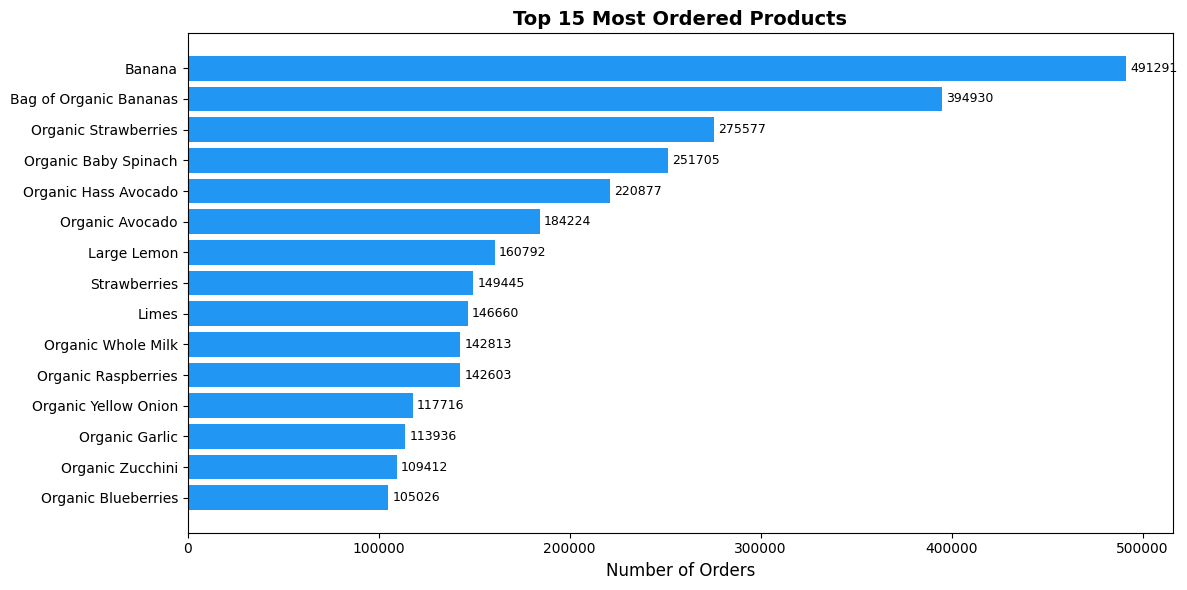

In [76]:
# Top 15 Most Ordered Products
top_products = cleaned_dataset.groupBy("product_name") \
    .agg(F.count("*").alias("order_count")) \
    .orderBy(F.desc("order_count")) \
    .limit(15) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_products['product_name'][::-1], top_products['order_count'][::-1], color='#2196F3')
ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_title('Top 15 Most Ordered Products', fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.show()

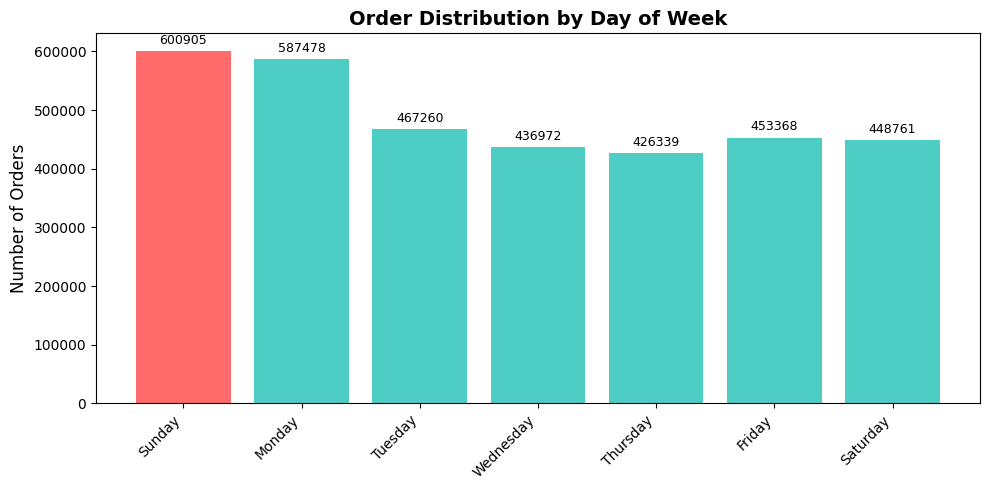

In [77]:
# Orders by Day of Week
dow_dist = orders_cleaned.groupBy("order_dow") \
    .agg(F.count("*").alias("order_count")) \
    .orderBy("order_dow") \
    .toPandas()

day_names = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
dow_dist['day_name'] = dow_dist['order_dow'].map(lambda x: day_names[x])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#FF6B6B' if x == dow_dist['order_count'].max() else '#4ECDC4' for x in dow_dist['order_count']]
ax.bar(dow_dist['day_name'], dow_dist['order_count'], color=colors)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Order Distribution by Day of Week', fontsize=14, fontweight='bold')
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

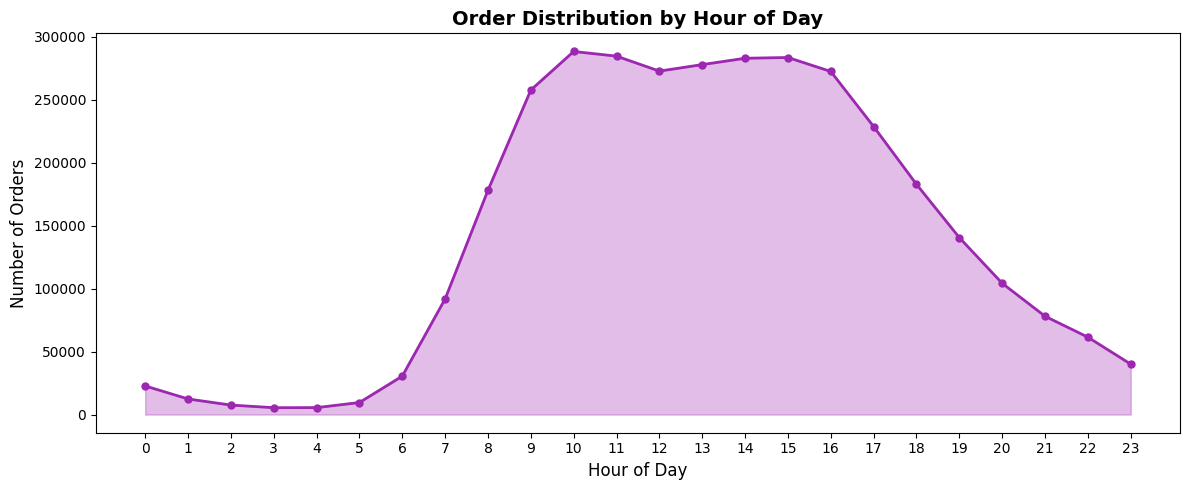

In [78]:
# Orders by Hour of Day
hour_dist = orders_cleaned.groupBy("order_hour_of_day") \
    .agg(F.count("*").alias("order_count")) \
    .orderBy("order_hour_of_day") \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(hour_dist['order_hour_of_day'], hour_dist['order_count'], alpha=0.3, color='#9C27B0')
ax.plot(hour_dist['order_hour_of_day'], hour_dist['order_count'], color='#9C27B0', linewidth=2, marker='o', markersize=5)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Order Distribution by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

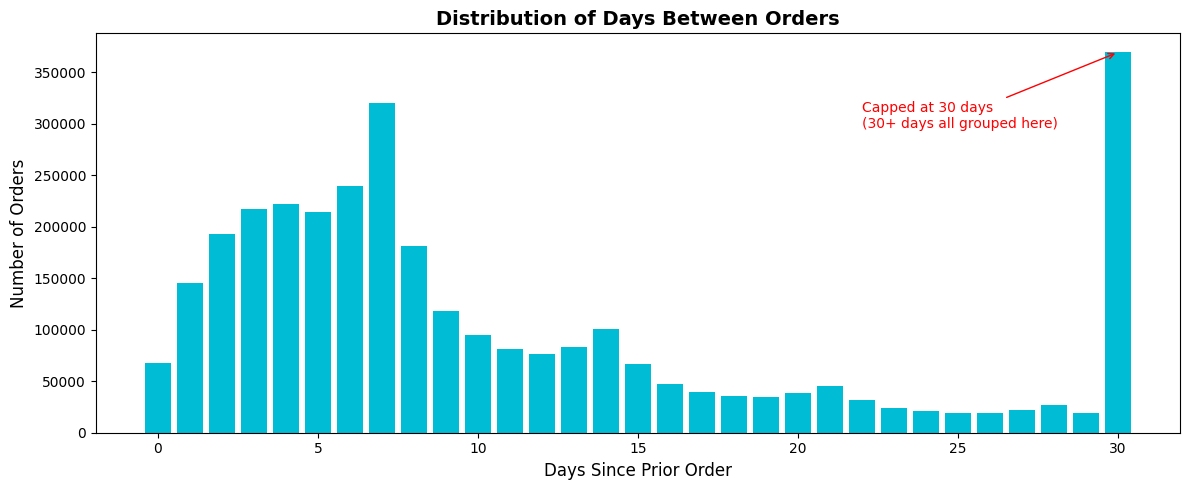

In [79]:
# Days Since Prior Order Distribution
days_dist = orders_cleaned.filter(F.col("is_first_order") == False) \
    .groupBy("days_since_prior_order") \
    .agg(F.count("*").alias("count")) \
    .orderBy("days_since_prior_order") \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(days_dist['days_since_prior_order'], days_dist['count'], color='#00BCD4', width=0.8)
ax.set_xlabel('Days Since Prior Order', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Distribution of Days Between Orders', fontsize=14, fontweight='bold')
ax.annotate('Capped at 30 days\n(30+ days all grouped here)',
            xy=(30, days_dist[days_dist['days_since_prior_order'] == 30]['count'].values[0]),
            xytext=(22, days_dist['count'].max() * 0.8),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')
plt.tight_layout()
plt.show()

In [80]:
COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF6B6B',
    'accent1': '#4ECDC4',
    'accent2': '#FF9800',
    'accent3': '#9C27B0',
    'accent4': '#8BC34A',
    'bg': '#FAFAFA',
    'text': '#333333'
}

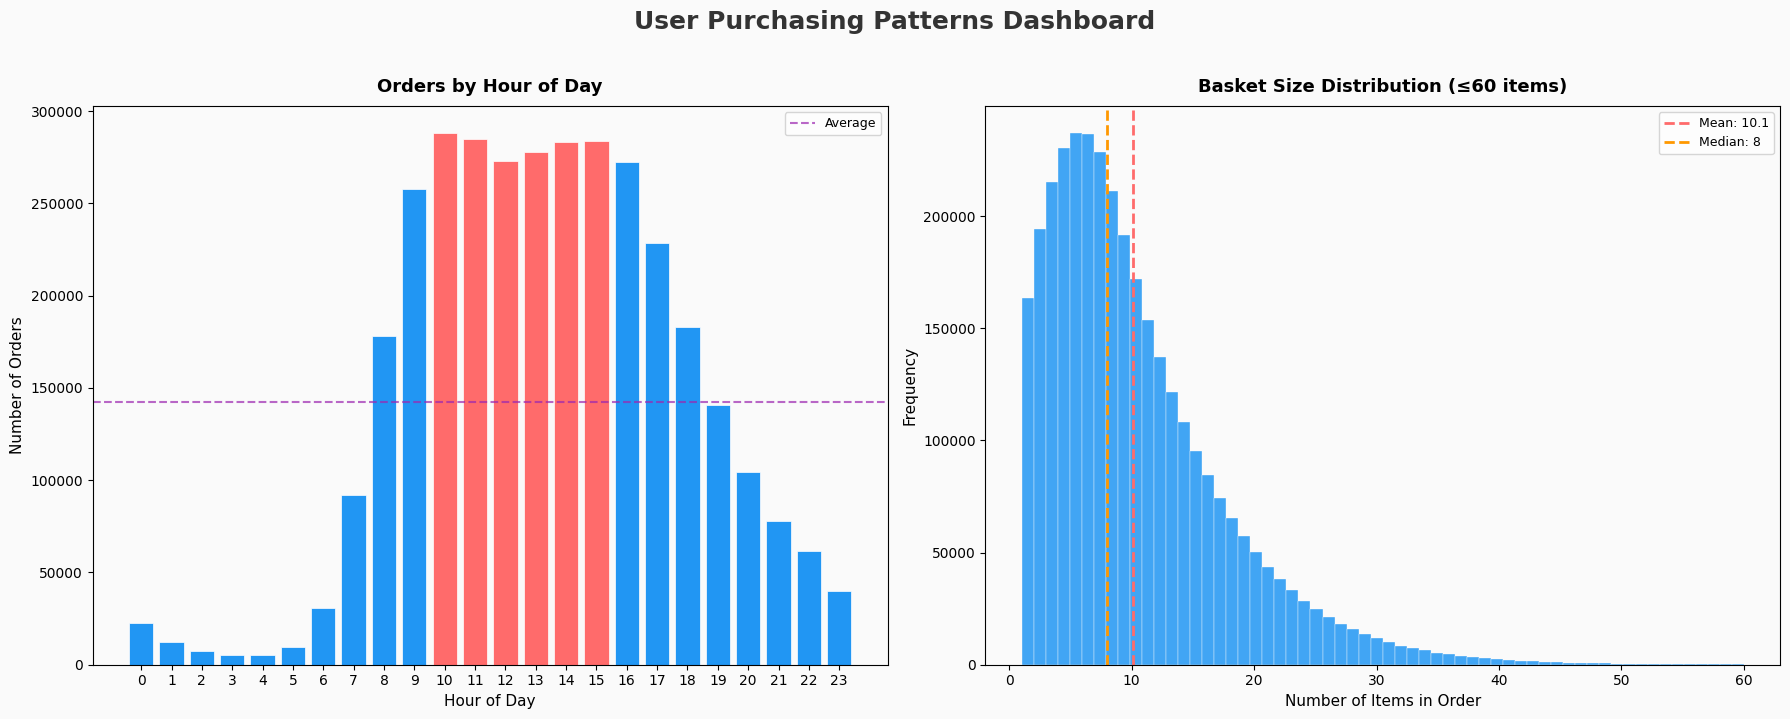

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('User Purchasing Patterns Dashboard',
             fontsize=18, fontweight='bold', y=1.02, color=COLORS['text'])
fig.patch.set_facecolor(COLORS['bg'])

# Orders by Hour of Day
hour_data = orders_cleaned.groupBy("order_hour_of_day") \
    .agg(F.count("*").alias("count")).orderBy("order_hour_of_day").toPandas()

ax = axes[0]
ax.set_facecolor(COLORS['bg'])
colors_hour = [COLORS['secondary'] if x >= hour_data['count'].quantile(0.75)
               else COLORS['primary'] for x in hour_data['count']]
ax.bar(hour_data['order_hour_of_day'], hour_data['count'], color=colors_hour, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Number of Orders', fontsize=11)
ax.set_title('Orders by Hour of Day', fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(range(0, 24))
ax.axhline(y=hour_data['count'].mean(), color=COLORS['accent3'], linestyle='--', alpha=0.7, label='Average')
ax.legend(fontsize=9)

# Basket Size Distribution
basket_pd = basket_size.filter(F.col("basket_size") <= 60).toPandas()

ax = axes[1]
ax.set_facecolor(COLORS['bg'])
ax.hist(basket_pd['basket_size'], bins=60, color=COLORS['primary'], edgecolor='white',
        linewidth=0.3, alpha=0.85)
ax.axvline(x=basket_pd['basket_size'].mean(), color=COLORS['secondary'],
           linestyle='--', linewidth=2, label=f'Mean: {basket_pd["basket_size"].mean():.1f}')
ax.axvline(x=basket_pd['basket_size'].median(), color=COLORS['accent2'],
           linestyle='--', linewidth=2, label=f'Median: {basket_pd["basket_size"].median():.0f}')
ax.set_xlabel('Number of Items in Order', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Basket Size Distribution (≤60 items)', fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=9)


plt.tight_layout()
plt.show()

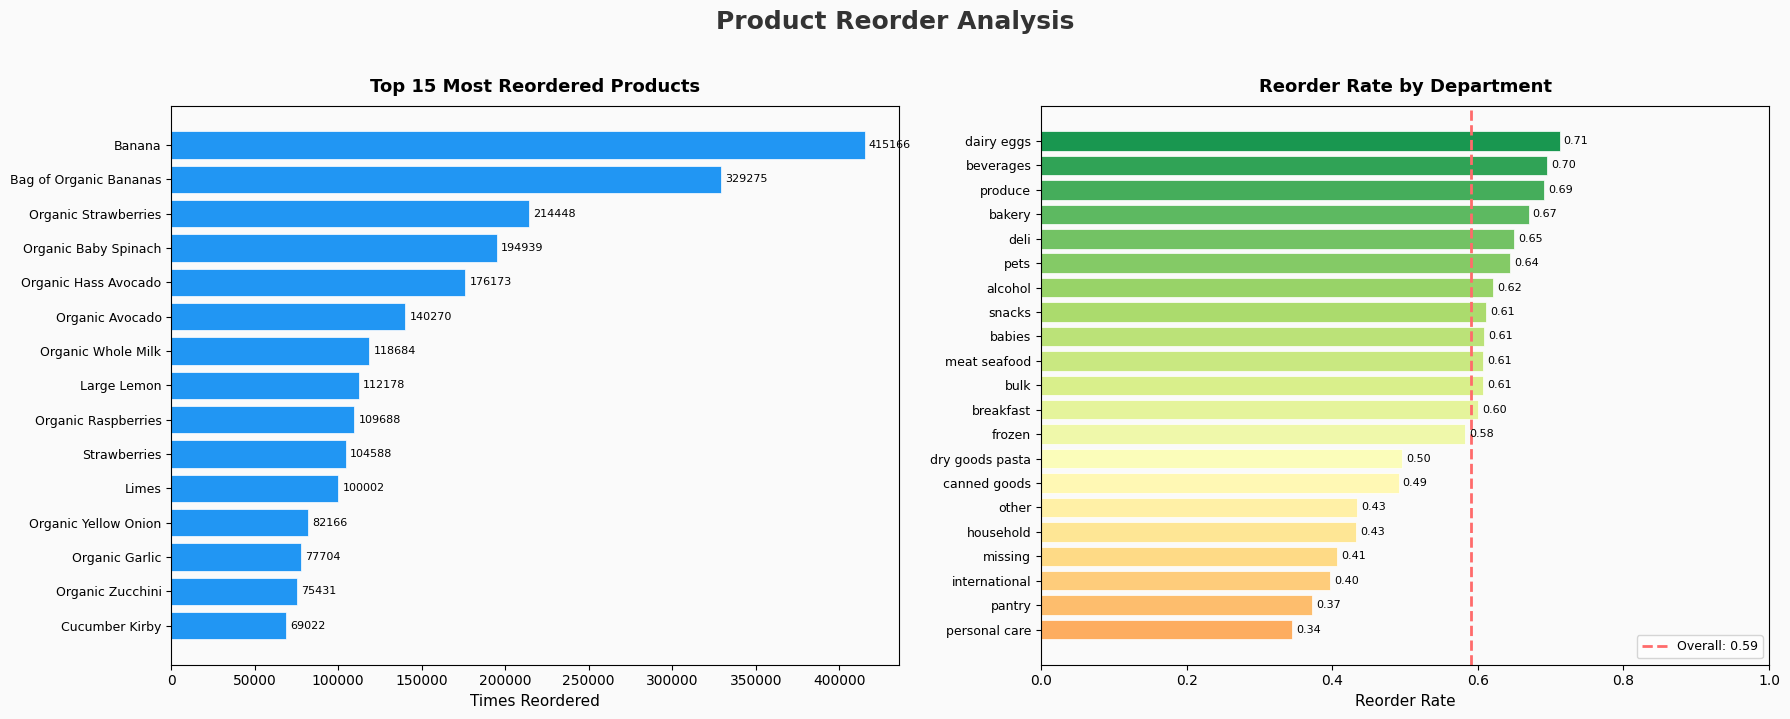

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Product Reorder Analysis',
             fontsize=18, fontweight='bold', y=1.02, color=COLORS['text'])
fig.patch.set_facecolor(COLORS['bg'])

# Top 15 Most Reordered Products
top_reordered = reorder_stats.orderBy(F.desc("times_reordered")).limit(15).toPandas()

ax = axes[0]
ax.set_facecolor(COLORS['bg'])
y_pos = range(len(top_reordered))
bars = ax.barh(top_reordered['product_name'][::-1],
               top_reordered['times_reordered'][::-1],
               color=COLORS['primary'], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Times Reordered', fontsize=11)
ax.set_title('Top 15 Most Reordered Products', fontsize=13, fontweight='bold', pad=10)
ax.bar_label(bars, fmt='%d', fontsize=8, padding=3)
ax.tick_params(axis='y', labelsize=9)

# Reorder Rate by Department
dept_reorder_pd = dept_reorder.toPandas()

ax = axes[1]
ax.set_facecolor(COLORS['bg'])
colors_dept = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(dept_reorder_pd)))
bars = ax.barh(dept_reorder_pd['department'][::-1],
               dept_reorder_pd['reorder_rate'][::-1],
               color=colors_dept, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Reorder Rate', fontsize=11)
ax.set_title('Reorder Rate by Department', fontsize=13, fontweight='bold', pad=10)
ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=3)
ax.set_xlim(0, 1)
ax.axvline(x=overall_reorder_rate, color=COLORS['secondary'], linestyle='--',
           linewidth=2, label=f'Overall: {overall_reorder_rate:.2f}')
ax.legend(fontsize=9, loc='lower right')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

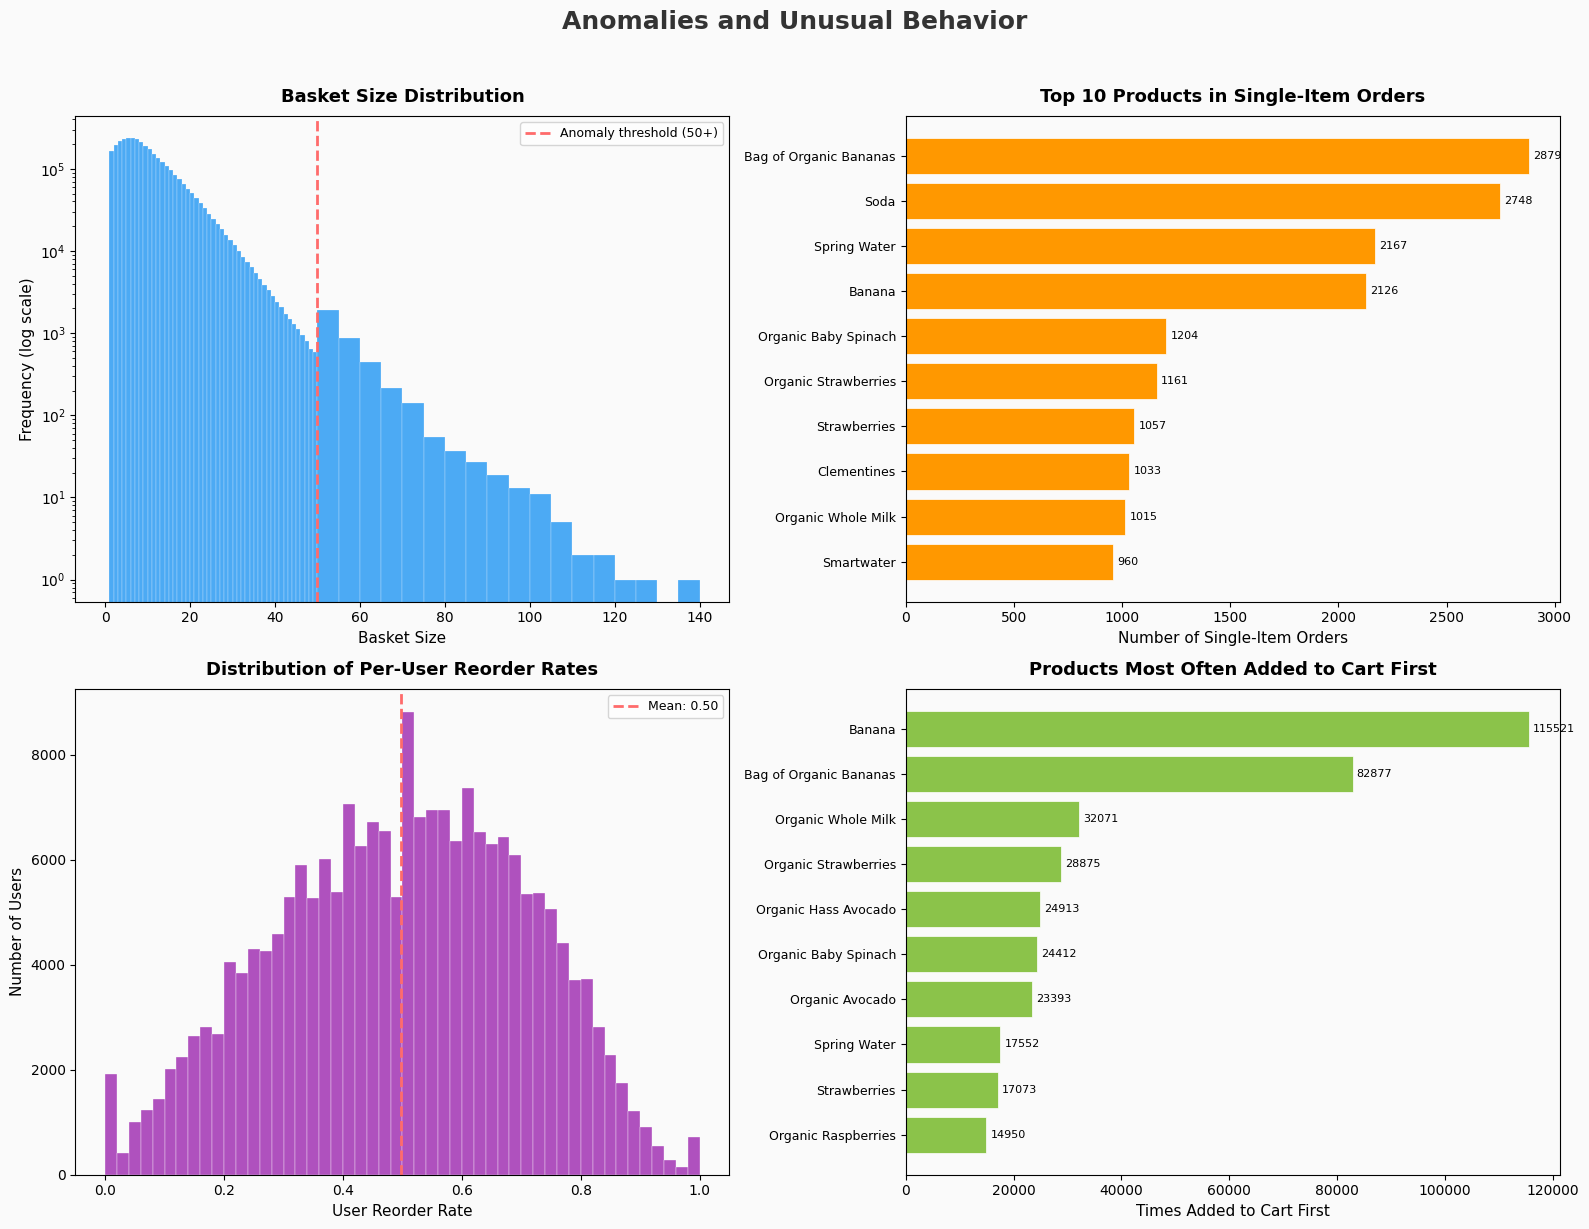

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Anomalies and Unusual Behavior',
             fontsize=18, fontweight='bold', y=1.02, color=COLORS['text'])
fig.patch.set_facecolor(COLORS['bg'])

# Basket size
basket_all = basket_size.toPandas()

ax = axes[0, 0]
ax.set_facecolor(COLORS['bg'])
bins = list(range(0, 50, 1)) + list(range(50, 145, 5))
ax.hist(basket_all['basket_size'], bins=bins, color=COLORS['primary'],
        edgecolor='white', linewidth=0.2, alpha=0.8, log=True)
ax.axvline(x=50, color=COLORS['secondary'], linestyle='--', linewidth=2, label='Anomaly threshold (50+)')
ax.set_xlabel('Basket Size', fontsize=11)
ax.set_ylabel('Frequency (log scale)', fontsize=11)
ax.set_title('Basket Size Distribution',
             fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=9)

# Single-item order products
single_pd = single_item_products.limit(10).toPandas()

ax = axes[0, 1]
ax.set_facecolor(COLORS['bg'])
bars = ax.barh(single_pd['product_name'][::-1], single_pd['single_order_count'][::-1],
               color=COLORS['accent2'], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of Single-Item Orders', fontsize=11)
ax.set_title('Top 10 Products in Single-Item Orders',
             fontsize=13, fontweight='bold', pad=10)
ax.bar_label(bars, fmt='%d', fontsize=8, padding=3)
ax.tick_params(axis='y', labelsize=9)

# User reorder rate distribution
user_reorder_rates = cleaned_dataset.filter(F.col("order_number") > 1) \
    .groupBy("user_id") \
    .agg(F.avg("reordered").alias("reorder_rate")) \
    .toPandas()

ax = axes[1, 0]
ax.set_facecolor(COLORS['bg'])
ax.hist(user_reorder_rates['reorder_rate'], bins=50, color=COLORS['accent3'],
        edgecolor='white', linewidth=0.3, alpha=0.8)
ax.axvline(x=user_reorder_rates['reorder_rate'].mean(), color=COLORS['secondary'],
           linestyle='--', linewidth=2,
           label=f'Mean: {user_reorder_rates["reorder_rate"].mean():.2f}')
ax.set_xlabel('User Reorder Rate', fontsize=11)
ax.set_ylabel('Number of Users', fontsize=11)
ax.set_title('Distribution of Per-User Reorder Rates',
             fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=9)

# Products always added first to cart
first_cart_pd = always_first.limit(10).toPandas()

ax = axes[1, 1]
ax.set_facecolor(COLORS['bg'])
bars = ax.barh(first_cart_pd['product_name'][::-1],
               first_cart_pd['times_added_first'][::-1],
               color=COLORS['accent4'], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Times Added to Cart First', fontsize=11)
ax.set_title('Products Most Often Added to Cart First',
             fontsize=13, fontweight='bold', pad=10)
ax.bar_label(bars, fmt='%d', fontsize=8, padding=3)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

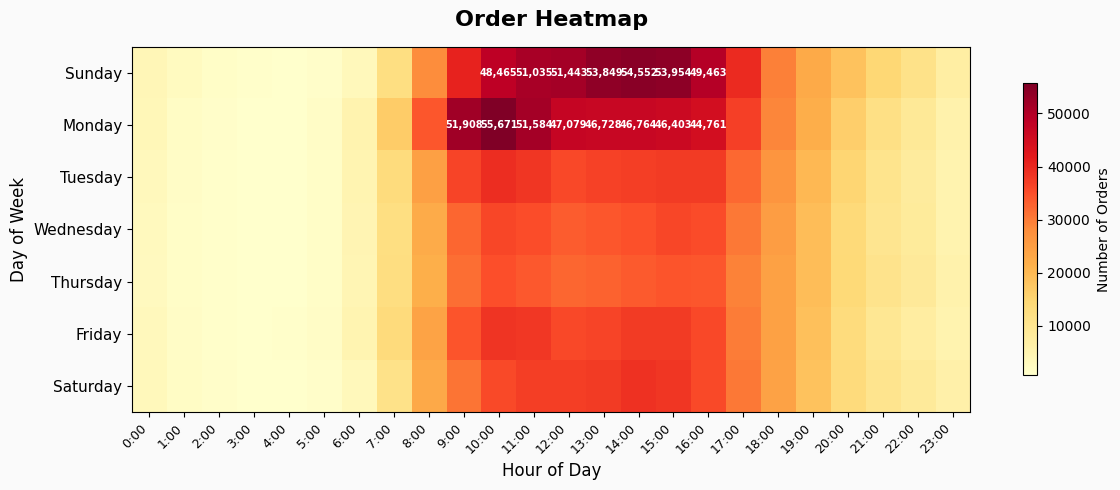

In [84]:
heatmap_data = orders_cleaned.groupBy("order_dow", "order_hour_of_day") \
    .agg(F.count("*").alias("order_count")) \
    .toPandas()

heatmap_pivot = heatmap_data.pivot_table(
    values='order_count',
    index='order_dow',
    columns='order_hour_of_day',
    fill_value=0
)
heatmap_pivot.index = [day_names[i] for i in heatmap_pivot.index]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

im = ax.imshow(heatmap_pivot.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h}:00' for h in range(24)], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(7))
ax.set_yticklabels(heatmap_pivot.index, fontsize=11)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.set_title('Order Heatmap',
             fontsize=16, fontweight='bold', pad=15)

cbar = plt.colorbar(im, ax=ax, shrink=0.8, label='Number of Orders')

threshold = heatmap_pivot.values.max() * 0.8
for i in range(heatmap_pivot.shape[0]):
    for j in range(heatmap_pivot.shape[1]):
        val = heatmap_pivot.values[i, j]
        if val >= threshold:
            ax.text(j, i, f'{int(val):,}', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

# Optional

#### DATA SCALE COMPARISON

| Table                    | Current         | At 100x              |
|--------------------------|----------------|----------------------|
| order_products (prior)   | 32.4M rows     | 3.24B rows           |
| order_products (train)   | 1.4M rows      | 140M rows            |
| orders                   | 3.4M rows      | 340M rows            |
| products                 | 49,688 rows    | 5M rows (possibly)   |
| aisles                   | 134 rows       | 13K rows             |
| departments              | 21 rows        | 2K rows              |
| **Estimated Data Size**  | **6-8 GB**     | **600-800 GB**       |
| **Users**                | **206K**       | **20M**              |

## "What breaks if data grows 100x?"

As the dataset grows from millions to **billions of rows**, several operations that work well at small scale become major bottlenecks.  

---

## 1. CSV Reading Bottleneck

### Problem
Using:

```python
spark.read.csv(..., inferSchema=True)
```

causes Spark to scan the entire dataset twice:

1. Infer column data types  
2. Read and parse the actual data

At **3.3B+ rows**, this becomes extremely expensive, especially for large non-columnar CSV files.

### Impact
- Very slow startup time
- High disk I/O
- Increased cluster resource usage
- Poor scalability for production workloads

### To Fix
Convert raw CSV files into **Parquet** format.

Benefits of Parquet:
- Columnar storage
- Reads only required columns
- Better compression
- Faster filtering and aggregation
- Optimized for Spark execution

---

## 2. Expensive Shuffle Operations

### Problem
Operations such as:

- `groupBy`
- `Window`
- `repartition`
- `join`

trigger heavy data shuffling across executors.

At 100× scale, shuffle traffic becomes extremely costly.

### Impact
- Long execution times
- Executor memory pressure
- Disk spill overhead
- Network bottlenecks

### To Fix

1. Scale partition count according to data size
2. Increase executor memory
3. Enable spill management
4. Use **Adaptive Query Execution (AQE)** for automatic optimization

---

## 3. `.toPandas()` Memory Risk

### Problem
Using:

```python
df.toPandas()
```

moves distributed Spark data into a single-machine Pandas DataFrame.

At large scale, this can easily exceed driver memory.

### Impact
- Driver crashes
- Out-of-memory errors
- Unstable notebooks

### To Fix
* Always aggregate or sample before converting.
* Prefer Spark-native visualization tools whenever possible.

---

## 4. Broadcast Join Limitations

### Problem
Current pipeline broadcasts:

- `products`
- `aisles`
- `departments`

At 100× scale:

| Table | Estimated Size |
|---|---|
| products | Up to 5M rows |
| aisles | ~13K rows |
| departments | ~2K rows |

`products` may approach or exceed Spark’s default broadcast threshold.

### Impact
- Broadcast failures
- Executor memory overload
- Slow joins

### To Fix

#### If `products` < 200 MB
Explicitly broadcast:

```python
from pyspark.sql.functions import broadcast
```

#### If `products` > 500 MB
Use **SortMergeJoin (SMJ)**

Additional optimizations:
- Pre-partition both tables by `product_id`
- Bucket tables on disk for recurring joins

---

## 5. Data Skew Problems

### Problem
At larger scale, data distribution becomes highly uneven.

Examples:
- Some users may have **10,000+ orders**
- Popular products (e.g. bananas) appear in billions of rows
- Weekends may contain 2× more orders than weekdays

### Impact
- Extremely slow tasks
- Straggler executors
- Uneven cluster utilization

### To Fix

* Enable AQE skew join handling
* Use **key salting** to distribute skewed partitions more evenly.

---

# Cluster Resource Requirements

### Current Situation
The existing pipeline can run on:
- Small Spark clusters
- A single machine

### At 100× Scale
Infrastructure requirements increase dramatically.

Expected requirements:
- Large distributed clusters
- High-memory executors
- Auto-scaling compute resources
- Optimized storage systems

---

## To Fix

* Use Cloud Auto-Scaling Clusters
* Use Spot / Preemptible Instances
* Enable Dynamic Allocation

---